In [17]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download lexicon and initialize analyzer
nltk.download('vader_lexicon', quiet=True)
vader = SentimentIntensityAnalyzer()

# Define paths
RAW_DATA_PATH = os.path.join('..', 'data', 'raw')
print(f"Environment ready. Path: {RAW_DATA_PATH}")

Environment ready. Path: ..\data\raw


In [18]:
def align_to_trading_day(date):
    """Handles weekends by moving news to the next trading day (Monday)."""
    if date.weekday() == 5: return date + pd.Timedelta(days=2) # Sat -> Mon
    if date.weekday() == 6: return date + pd.Timedelta(days=1) # Sun -> Mon
    return date

def get_sentiment_score(text):
    """Assigns a numerical sentiment score using VADER."""
    if pd.isna(text): return 0.0
    return vader.polarity_scores(str(text))['compound']

def categorize_sentiment(score):
    """Classifies scores into Negative, Neutral, or Positive."""
    if score > 0.05: return 'Positive'
    if score < -0.05: return 'Negative'
    return 'Neutral'

In [19]:
print("Loading news data...")
news = pd.read_csv(os.path.join(RAW_DATA_PATH, 'raw_analyst_ratings.csv'), 
                   usecols=['date', 'stock', 'headline'])

# Handle timezones and normalize dates
news['date'] = pd.to_datetime(news['date'], errors='coerce', utc=True).dt.tz_localize(None)
news = news.dropna(subset=['date'])

# Apply weekend alignment and extract date only
news['date'] = news['date'].apply(align_to_trading_day).dt.date

print("Calculating sentiment scores...")
news['sentiment'] = news['headline'].apply(get_sentiment_score)

# Aggregate multiple articles per day per stock
daily_news = news.groupby(['date', 'stock'])['sentiment'].mean().reset_index()
daily_news.columns = ['date', 'ticker', 'avg_sentiment']
daily_news['date'] = pd.to_datetime(daily_news['date'])

print(f"Processed {len(daily_news)} daily sentiment records.")

Loading news data...
Calculating sentiment scores...
Processed 44102 daily sentiment records.


In [20]:
target_stocks = ['AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'META.csv', 'NVDA.csv']
all_stock_returns = []

for f in target_stocks:
    path = os.path.join(RAW_DATA_PATH, f)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
        
        # Requirement: Calculate Daily Stock Returns %
        df = df.sort_values('Date')
        df['daily_return'] = df['Close'].pct_change() * 100
        
        df['ticker'] = f.replace('.csv', '')
        all_stock_returns.append(df[['Date', 'ticker', 'daily_return']])

stocks_df = pd.concat(all_stock_returns)
stocks_df = stocks_df.rename(columns={'Date': 'date'})
print(f"Calculated returns for {len(target_stocks)} stock files.")

Calculated returns for 5 stock files.


In [23]:
# Force both to datetime objects right before merging
daily_news['date'] = pd.to_datetime(daily_news['date'])
stocks_df['date'] = pd.to_datetime(stocks_df['date'])

# Perform the merge
final_df = pd.merge(daily_news, stocks_df, on=['date', 'ticker'], how='inner')

print(f"Rows matched: {len(final_df)}")

Rows matched: 14


Pearson Correlation: 0.0868


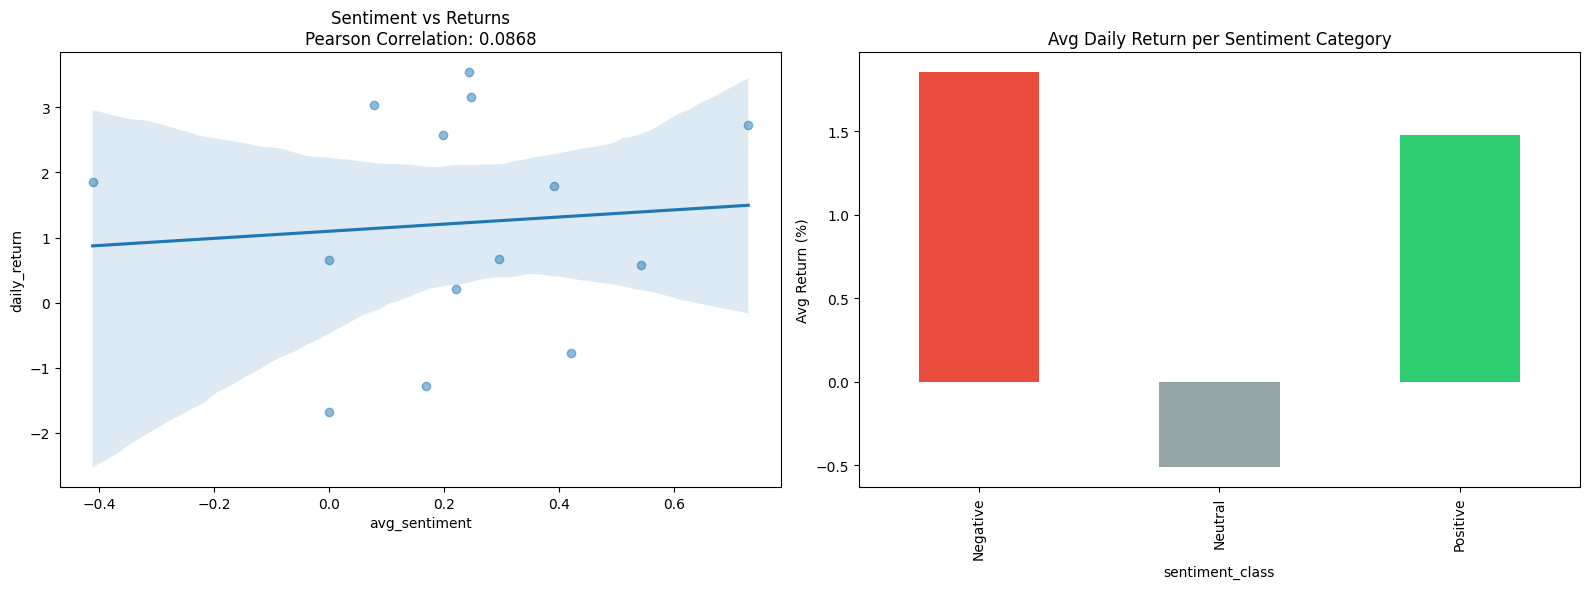

In [26]:
# 1. Pearson Correlation
# Verify data exists before plotting
if not final_df.empty:
    corr_value = final_df['avg_sentiment'].corr(final_df['daily_return'])
    print(f"Pearson Correlation: {corr_value:.4f}")
    
    # Classification logic
    def categorize(s):
        if s > 0.05: return 'Positive'
        if s < -0.05: return 'Negative'
        return 'Neutral'
    
    final_df['sentiment_class'] = final_df['avg_sentiment'].apply(categorize)
else:
    print("❌ Error: final_df is empty. Check your merge cell!")
correlation = final_df['avg_sentiment'].corr(final_df['daily_return'])

# 2. Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
sns.regplot(data=final_df, x='avg_sentiment', y='daily_return', ax=ax1, scatter_kws={'alpha':0.5})
ax1.set_title(f'Sentiment vs Returns\nPearson Correlation: {correlation:.4f}')

# Bar Chart
category_returns = final_df.groupby('sentiment_class')['daily_return'].mean().reindex(['Negative', 'Neutral', 'Positive'])
category_returns.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'], ax=ax2)
ax2.set_title('Avg Daily Return per Sentiment Category')
ax2.set_ylabel('Avg Return (%)')

plt.tight_layout()
plt.show()